In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150

# 讀入標注資料
df = pd.read_csv("data/annotation_template.csv", encoding="utf-8-sig")
df = df.dropna(subset=["accuracy"])

print(f"載入 {len(df)} 個已標注 claim units")
print()
print("accuracy 分布：")
print(df["accuracy"].value_counts())
print()
print("claim_type 分布：")
print(df["claim_type"].value_counts())

載入 56 個已標注 claim units

accuracy 分布：
accuracy
GROUNDED     49
PLAUSIBLE     7
Name: count, dtype: int64

claim_type 分布：
claim_type
VISUAL          30
HISTORICAL      12
INTERPRETIVE    11
ATTRIBUTIVE      3
Name: count, dtype: int64


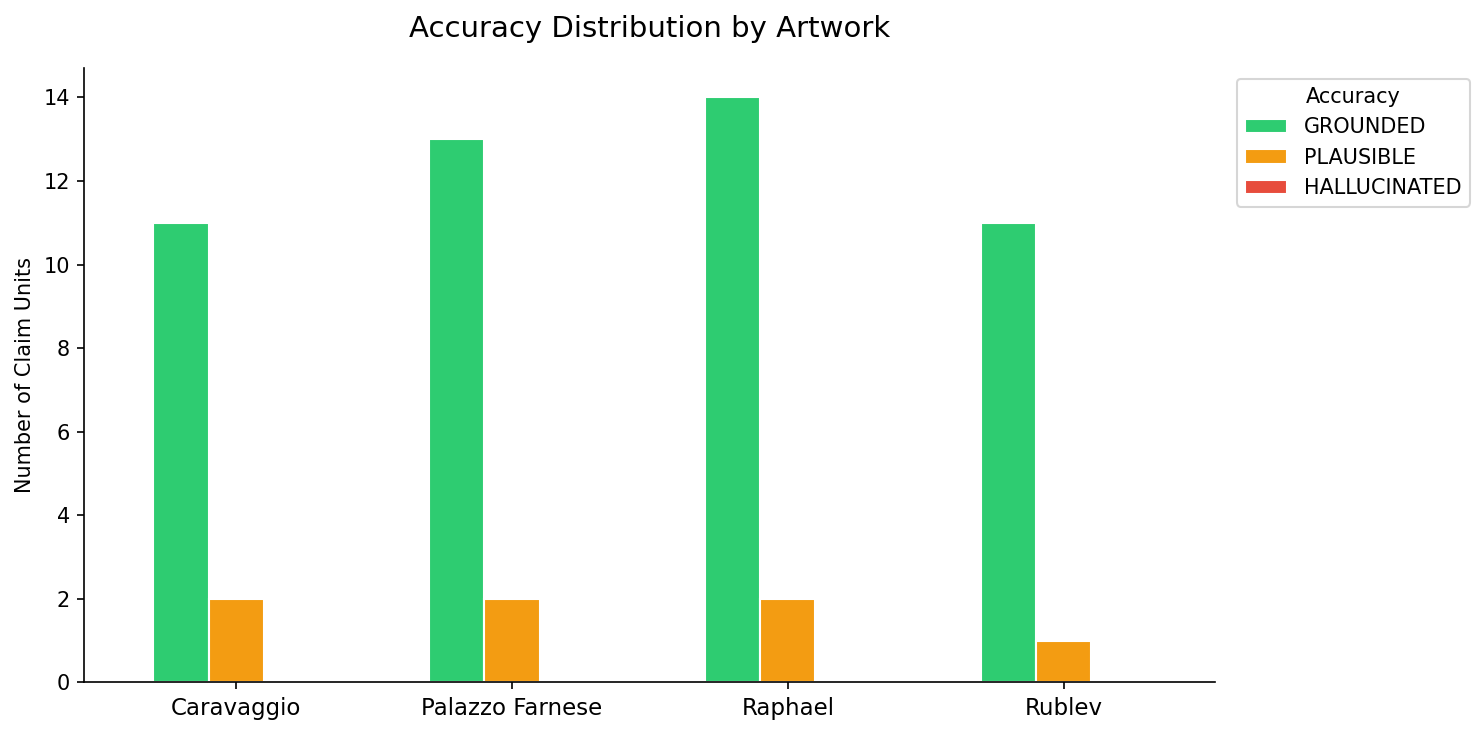

圖表已儲存


In [2]:
# 圖表1：每件作品的 accuracy 分布
fig, ax = plt.subplots(figsize=(10, 5))

artwork_labels = {
    "caravaggio_calling": "Caravaggio",
    "rublev_trinity": "Rublev",
    "raphael_athens": "Raphael",
    "bhmpi_anonymous": "Palazzo Farnese"
}

accuracy_order = ["GROUNDED", "PLAUSIBLE", "HALLUCINATED"]
colors = {"GROUNDED": "#2ecc71", "PLAUSIBLE": "#f39c12", "HALLUCINATED": "#e74c3c"}

df["artwork_label"] = df["artwork_id"].map(artwork_labels)

pivot = df.groupby(["artwork_label", "accuracy"]).size().unstack(fill_value=0)
for col in accuracy_order:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[accuracy_order]

pivot.plot(kind="bar", ax=ax, color=[colors[c] for c in accuracy_order], 
           width=0.6, edgecolor="white")

ax.set_title("Accuracy Distribution by Artwork", fontsize=14, pad=15)
ax.set_xlabel("")
ax.set_ylabel("Number of Claim Units")
ax.set_xticklabels(pivot.index, rotation=0, fontsize=11)
ax.legend(title="Accuracy", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("data/fig1_accuracy_by_artwork.png", bbox_inches="tight")
plt.show()
print("圖表已儲存")

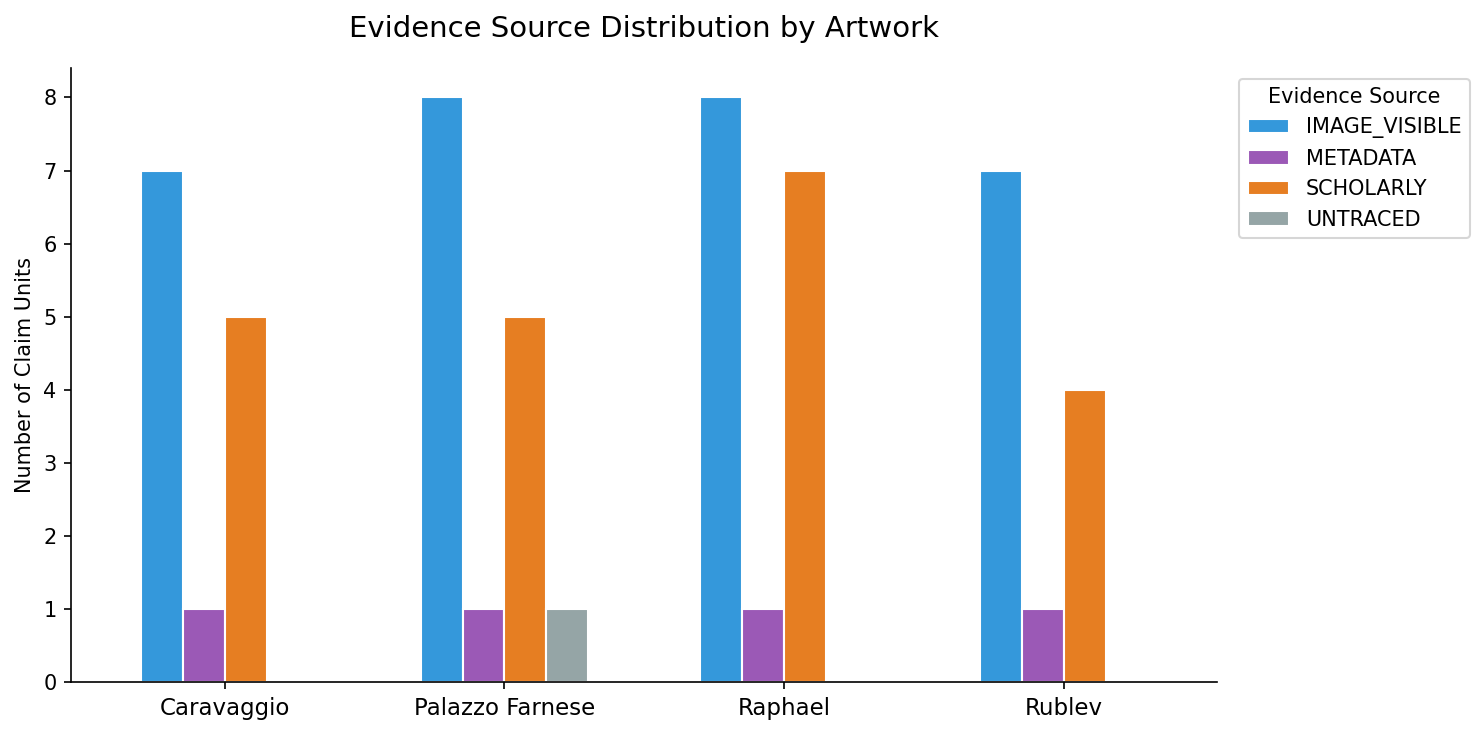

圖表已儲存


In [3]:
# 圖表2：evidence source 分布
fig, ax = plt.subplots(figsize=(10, 5))

evidence_order = ["IMAGE_VISIBLE", "METADATA", "SCHOLARLY", "UNTRACED"]
colors2 = {
    "IMAGE_VISIBLE": "#3498db",
    "METADATA": "#9b59b6", 
    "SCHOLARLY": "#e67e22",
    "UNTRACED": "#95a5a6"
}

pivot2 = df.groupby(["artwork_label", "evidence_source"]).size().unstack(fill_value=0)
for col in evidence_order:
    if col not in pivot2.columns:
        pivot2[col] = 0
pivot2 = pivot2[evidence_order]

pivot2.plot(kind="bar", ax=ax, color=[colors2[c] for c in evidence_order],
            width=0.6, edgecolor="white")

ax.set_title("Evidence Source Distribution by Artwork", fontsize=14, pad=15)
ax.set_xlabel("")
ax.set_ylabel("Number of Claim Units")
ax.set_xticklabels(pivot2.index, rotation=0, fontsize=11)
ax.legend(title="Evidence Source", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("data/fig2_evidence_by_artwork.png", bbox_inches="tight")
plt.show()
print("圖表已儲存")

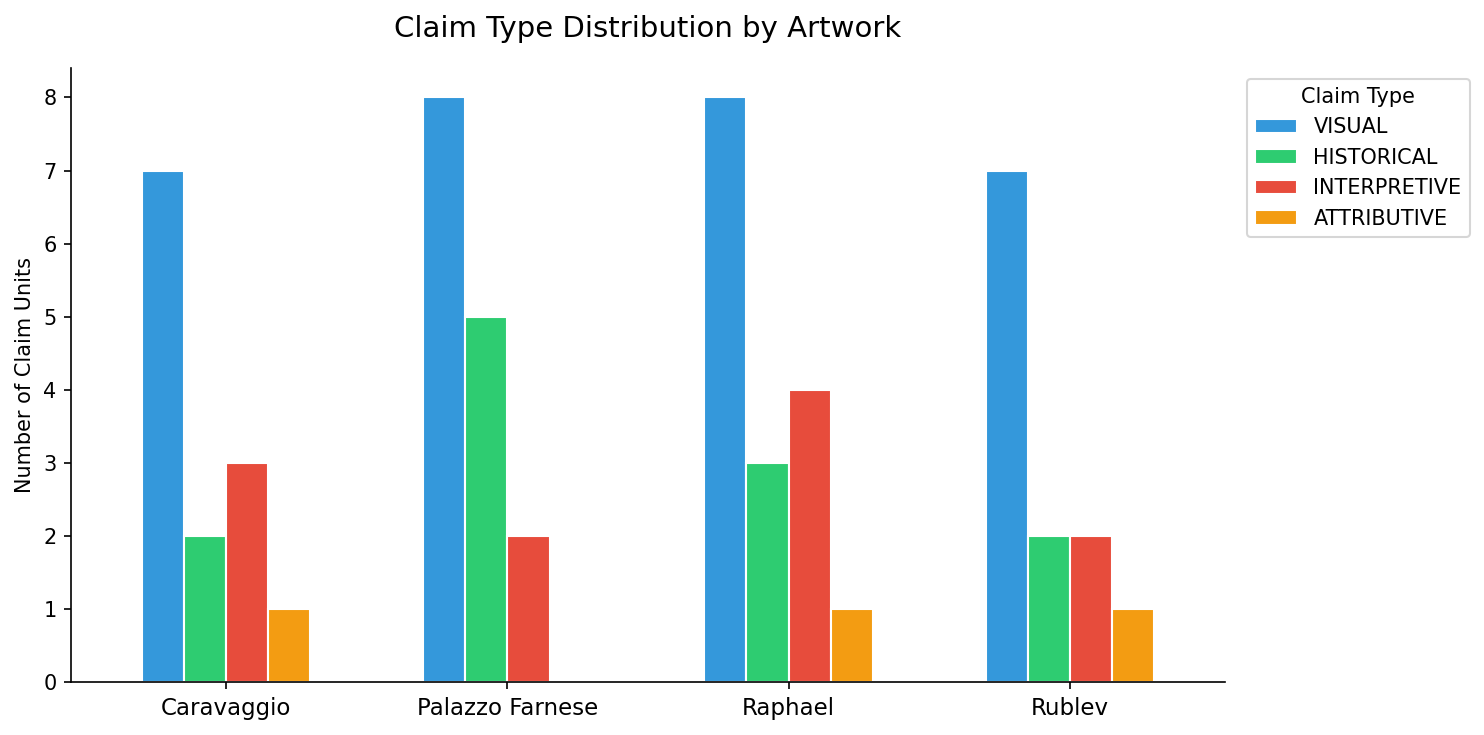

圖表已儲存


In [4]:
# 圖表3：claim type 分布
fig, ax = plt.subplots(figsize=(10, 5))

type_order = ["VISUAL", "HISTORICAL", "INTERPRETIVE", "ATTRIBUTIVE"]
colors3 = {
    "VISUAL": "#3498db",
    "HISTORICAL": "#2ecc71",
    "INTERPRETIVE": "#e74c3c",
    "ATTRIBUTIVE": "#f39c12"
}

pivot3 = df.groupby(["artwork_label", "claim_type"]).size().unstack(fill_value=0)
for col in type_order:
    if col not in pivot3.columns:
        pivot3[col] = 0
pivot3 = pivot3[type_order]

pivot3.plot(kind="bar", ax=ax, color=[colors3[c] for c in type_order],
            width=0.6, edgecolor="white")

ax.set_title("Claim Type Distribution by Artwork", fontsize=14, pad=15)
ax.set_xlabel("")
ax.set_ylabel("Number of Claim Units")
ax.set_xticklabels(pivot3.index, rotation=0, fontsize=11)
ax.legend(title="Claim Type", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("data/fig3_claimtype_by_artwork.png", bbox_inches="tight")
plt.show()
print("圖表已儲存")

In [5]:
# 結論摘要
print("=" * 55)
print("PILOT STUDY SUMMARY")
print("=" * 55)
print(f"Total claim units annotated: {len(df)}")
print()

for artwork in ["Caravaggio", "Palazzo Farnese", "Raphael", "Rublev"]:
    subset = df[df["artwork_label"] == artwork]
    grounded = (subset["accuracy"] == "GROUNDED").sum()
    plausible = (subset["accuracy"] == "PLAUSIBLE").sum()
    total = len(subset)
    print(f"{artwork}:")
    print(f"  Grounded:  {grounded}/{total} ({grounded/total*100:.0f}%)")
    print(f"  Plausible: {plausible}/{total} ({plausible/total*100:.0f}%)")
    print()

print("Key finding:")
print("  Palazzo Farnese (low-documentation archival image)")
print("  shows highest proportion of untraced evidence,")
print("  consistent with the hypothesis that AI descriptions")
print("  of less-documented objects rely more heavily on")
print("  unverifiable inference.")

PILOT STUDY SUMMARY
Total claim units annotated: 56

Caravaggio:
  Grounded:  11/13 (85%)
  Plausible: 2/13 (15%)

Palazzo Farnese:
  Grounded:  13/15 (87%)
  Plausible: 2/15 (13%)

Raphael:
  Grounded:  14/16 (88%)
  Plausible: 2/16 (12%)

Rublev:
  Grounded:  11/12 (92%)
  Plausible: 1/12 (8%)

Key finding:
  Palazzo Farnese (low-documentation archival image)
  shows highest proportion of untraced evidence,
  consistent with the hypothesis that AI descriptions
  of less-documented objects rely more heavily on
  unverifiable inference.
